In [1]:
import os
import sys
path = os.getcwd()
while True:
    if 'utils.py' in os.listdir(path):
        if path not in sys.path:
            sys.path.append(path)
        break
    new_path = os.path.dirname(path)
    if new_path == path:
        upload_utils = files.upload()
        break
    path = new_path

import utils
import matplotlib.pyplot as plt
import pandas as pd

Saving to: /Users/georgedikaios/Desktop/DAMA_EAP/NLI_Study/Notebooks/QNLI_Notebooks/QNLI_Llama_3.2_3B_Instruct/Results/checkpoint_qnli_Llama_3.2_3B_Instruct_full_zero_shot_chat_template.pt
Checkpoint found.
Saving to: /Users/georgedikaios/Desktop/DAMA_EAP/NLI_Study/Notebooks/QNLI_Notebooks/QNLI_Llama_3.2_3B_Instruct/Results/checkpoint_qnli_Llama_3.2_3B_Instruct_full_few_shot_1_examples_entailment_chat_template.pt
Checkpoint found.
Saving to: /Users/georgedikaios/Desktop/DAMA_EAP/NLI_Study/Notebooks/QNLI_Notebooks/QNLI_Llama_3.2_3B_Instruct/Results/checkpoint_qnli_Llama_3.2_3B_Instruct_full_few_shot_1_examples_not_entailment_chat_template.pt
Checkpoint found.
Saving to: /Users/georgedikaios/Desktop/DAMA_EAP/NLI_Study/Notebooks/QNLI_Notebooks/QNLI_Llama_3.2_3B_Instruct/Results/checkpoint_qnli_Llama_3.2_3B_Instruct_full_few_shot_2_examples_chat_template.pt
Checkpoint found.
Saving to: /Users/georgedikaios/Desktop/DAMA_EAP/NLI_Study/Notebooks/QNLI_Notebooks/QNLI_Llama_3.2_3B_Instruct/Resul

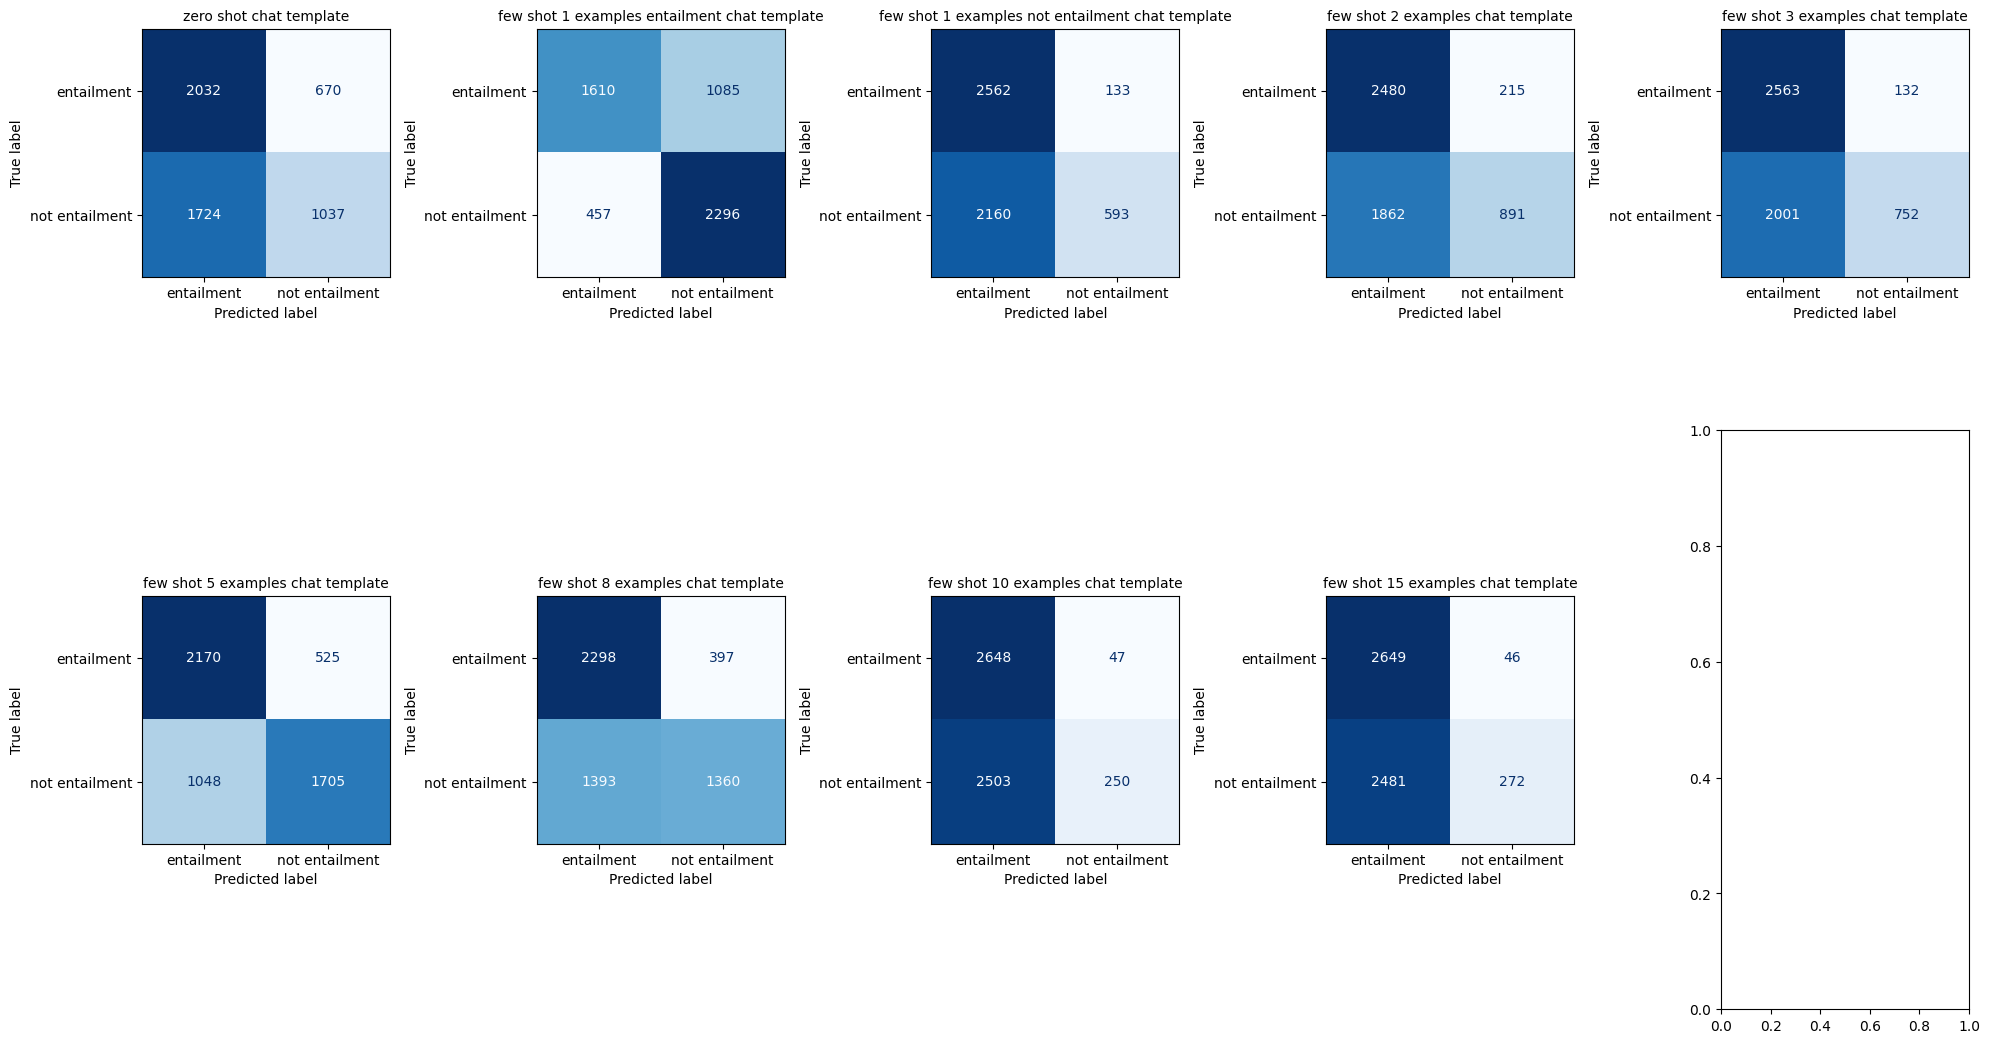

In [2]:
training_modes = [
    'zero shot chat template',
    'few shot 1 examples entailment chat template',
    'few shot 1 examples not entailment chat template',
    'few shot 2 examples chat template',
    'few shot 3 examples chat template',
    'few shot 5 examples chat template',
    'few shot 8 examples chat template',
    'few shot 10 examples chat template',
    'few shot 15 examples chat template'    
]

fig, axes = plt.subplots(2, 5, figsize=(20,12))
axes = axes.flatten()
accs, precisions, recalls, f1s, mccs, kappas = [], [], [], [], [], []

for idx, mode in enumerate(training_modes):
    global_params = {'dataset_type': 'qnli',
                'quantization': 'full',
                'training_mode': mode,
                'model_id': 'meta-llama/Llama-3.2-3B-Instruct'}
   
    checkpoint_path = utils.create_checkpoint_path(params=global_params)
    predicted_labels, gold_labels, _ = utils.load_checkpoint(checkpoint_path)

    acc, precision, recall, f1, mcc, kappa = utils.get_metrics(
                                            predicted_labels=predicted_labels,
                                            gold_labels=gold_labels,
                                            params=global_params,
                                            ax=axes[idx]
                                            )   
    accs.append(round(acc, 4))
    precisions.append(round(precision, 4))
    recalls.append(round(recall, 4))
    f1s.append(round(f1, 4))
    mccs.append(round(mcc, 4))
    kappas.append(round(kappa, 4))

plt.tight_layout()
plt.show()

In [3]:
labels = [
    "0 examples",
    "1 example (entailment)",
    "1 example (not entailment)",
    "2 examples",
    "3 examples",
    "5 examples",
    "8 examples",
    "10 examples",
    "15 examples"
]

metrics_df_chat_template = pd.DataFrame(
    {"Accuracy": accs,
     "Precision": precisions,
     "Recalls": recalls,
     "F1": f1s,
     "MCC": mccs,
     "Kappa": kappas},
     index= labels
)
metrics_df_chat_template

,Accuracy,Precision,Recalls,F1,MCC,Kappa
0 examples,0.5618,0.5742,0.5638,0.5467,0.1377,0.1271
1 example (entailment),0.7170,0.7290,0.7157,0.7124,0.4445,0.4325
1 example (not entailment),0.5791,0.6797,0.5830,0.5159,0.2443,0.1647
2 examples,0.6188,0.6884,0.6219,0.5833,0.3031,0.2423
3 examples,0.6085,0.7061,0.6121,0.5598,0.3040,0.2226
5 examples,0.7113,0.7195,0.7123,0.7092,0.4317,0.4237
8 examples,0.6714,0.6983,0.6733,0.6614,0.3708,0.3454
10 examples,0.5319,0.6779,0.5367,0.4195,0.1616,0.0727
15 examples,0.5362,0.6859,0.5409,0.4271,0.1743,0.0810


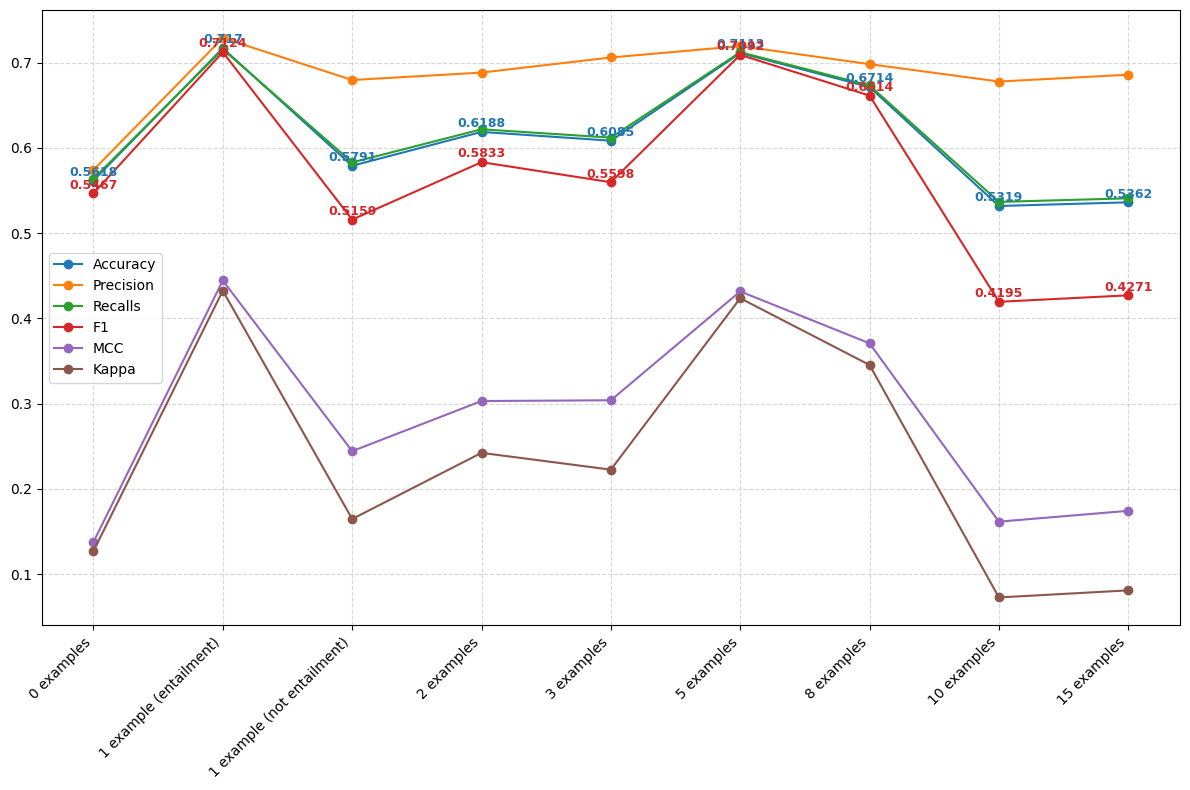

In [4]:
fig, ax = plt.subplots(figsize=(12, 8))

# plot all metrics
metrics_df_chat_template.plot(kind='line', ax=ax, marker='o')

# set custom x-axis labels
ax.set_xticks(range(len(metrics_df_chat_template.index)))
ax.set_xticklabels(metrics_df_chat_template.index, rotation=45, ha='right')

# show grid
ax.grid(True, linestyle='--', alpha=0.5)

# annotate only Accuracy and F1
for metric in ["Accuracy", "F1"]:
    for x, y in enumerate(metrics_df_chat_template[metric]):
        ax.text(x, y + 0.002, str(y), ha='center', va='bottom', fontsize=9, fontweight='bold', color=ax.get_lines()[list(metrics_df_chat_template.columns).index(metric)].get_color())

plt.tight_layout()
plt.show()